# Exploratory Data Analysis

## Import Libraries

In [54]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

## Loading the Dataset

In [3]:
df = pd.read_csv("../dataset/processed/GA0151_intersection.csv")

## 1. Data Overview

### 1.1 Shape of the dataset

In [6]:
df.shape

(33644, 5)

### 1.2 Date Range

In [10]:
print(f"Date range - {df['date'].min()} to {df['date'].max()}")

Date range - 2019-10-01 to 2023-09-30


## 2. Data Quality

### 2.1 Checking Missing Values

In [12]:
df.isnull().sum()

date        0
time        0
GA0151_A    0
GA0151_C    0
GA0151_D    0
dtype: int64

### 2.2 Checking for duplicates

In [17]:
print("Duplicates Rows:", df.duplicated().sum())

Duplicates Rows: 0


### 2.3 Basic Statistical Check

In [19]:
print(round(df.describe(),2))

           time  GA0151_A  GA0151_C  GA0151_D
count  33644.00  33644.00  33644.00  33644.00
mean      11.52     31.94    119.10     73.79
std        6.92     25.04     76.75     52.94
min        0.00      0.00      0.00      0.00
25%        6.00     11.00     42.00     24.00
50%       12.00     30.00    126.00     68.00
75%       18.00     46.00    186.00    116.00
max       23.00    260.00    405.00    300.00


### 2.4 Outlier Check

In [28]:
cols = ['GA0151_A', 'GA0151_C', 'GA0151_D']
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outlier = (df[cols] < lower) | (df[cols] > upper)
print("Outlier per sensor:\n", outlier.sum())

Outlier per sensor:
 GA0151_A    516
GA0151_C      1
GA0151_D     31
dtype: int64


## 3. Individual Sensor Analysis

### 3.1 Distribution

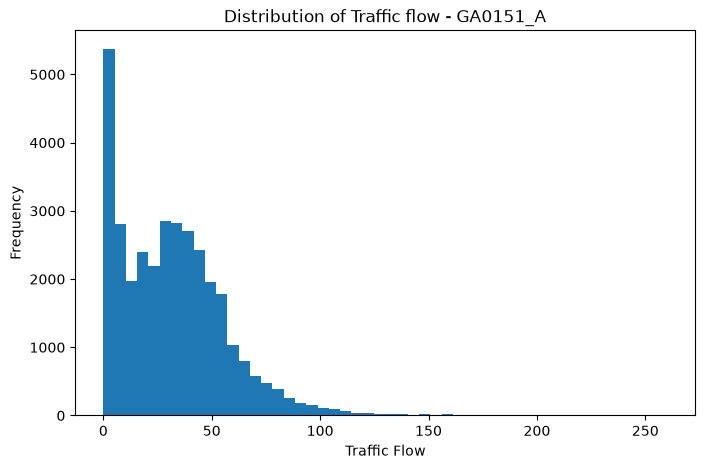

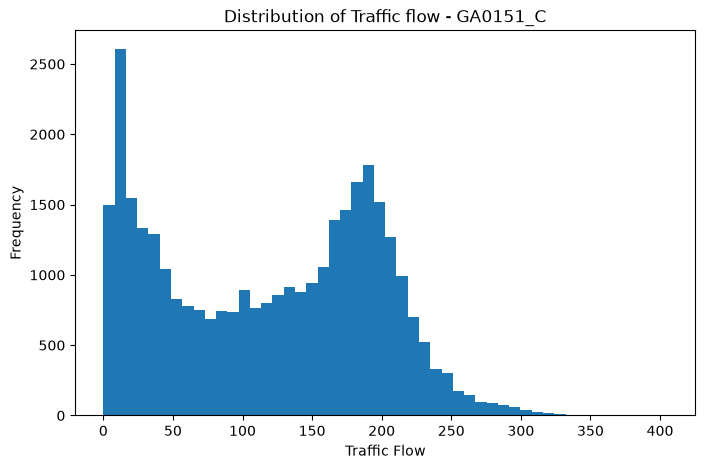

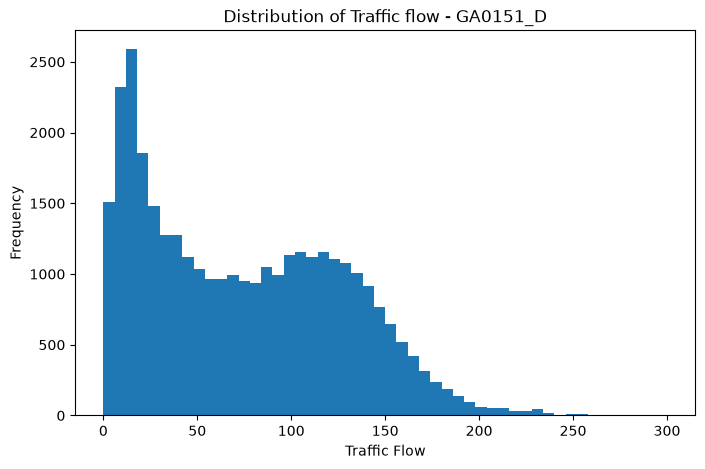

In [31]:
sensors = ['GA0151_A', 'GA0151_C', 'GA0151_D']
for sensor in sensors:
    plt.figure(figsize=(8, 5))
    plt.hist(df[sensor], bins=50)
    plt.title(f"Distribution of Traffic flow - {sensor}")
    plt.xlabel("Traffic Flow")
    plt.ylabel("Frequency")
    plt.show()


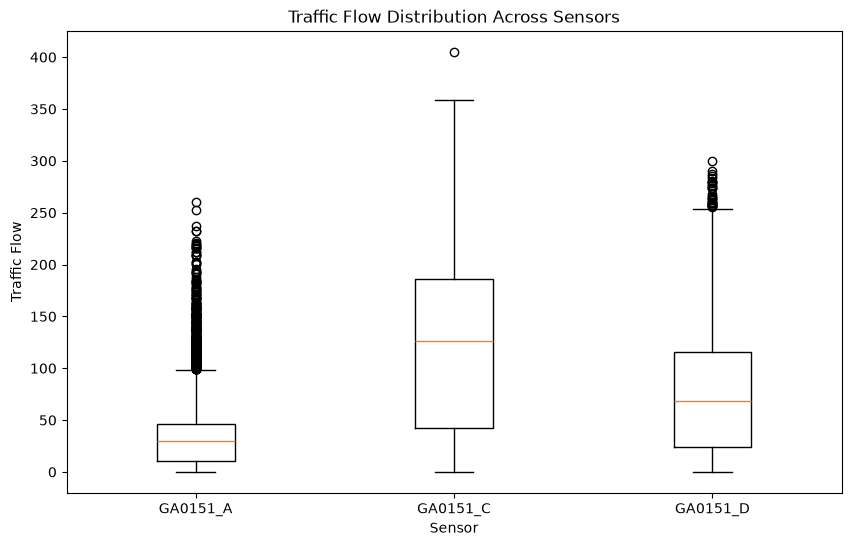

In [41]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [df[sensor].dropna() for sensor in sensors],
    tick_labels=sensors
)

plt.title('Traffic Flow Distribution Across Sensors')
plt.xlabel('Sensor')
plt.ylabel('Traffic Flow')
plt.show()

### Monthly Pattern

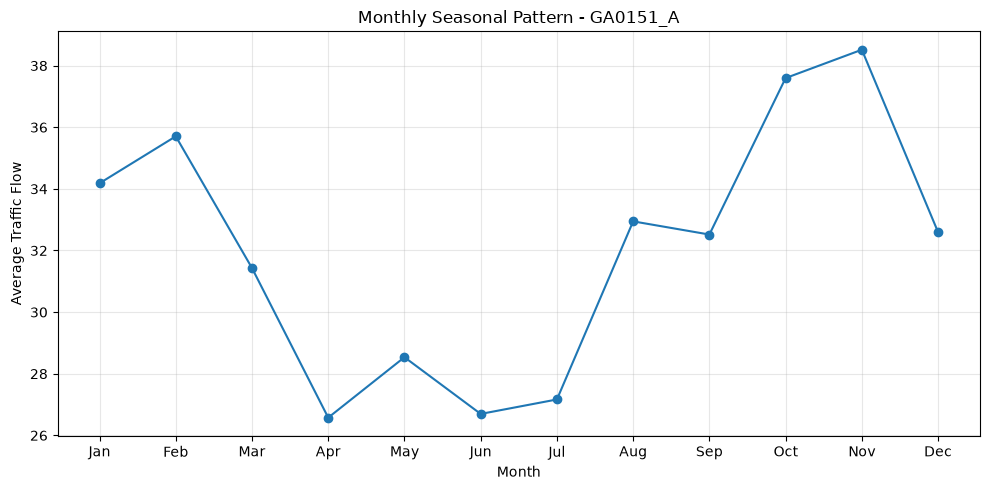

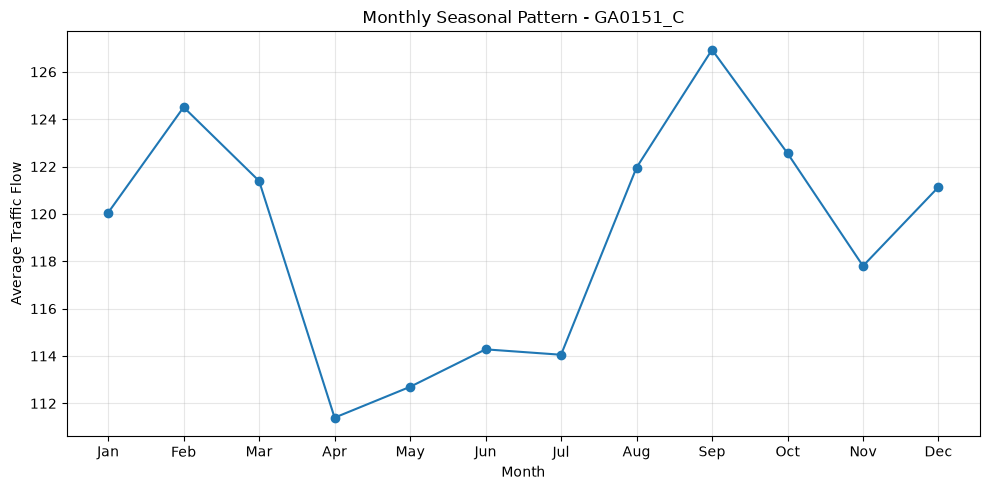

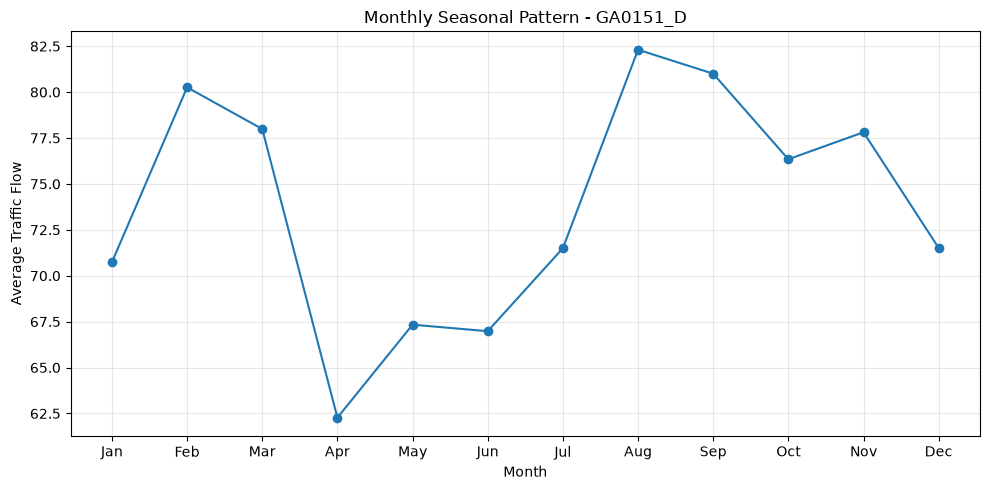

In [46]:
for sensor in sensors:

    monthly_pattern = df.groupby(
        df['date'].dt.month
    )[sensor].mean()

    plt.figure(figsize=(10, 5))

    plt.plot(
        monthly_pattern.index,
        monthly_pattern.values,
        marker='o'
    )

    plt.xticks(
        range(1, 13),
        ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    )

    plt.title(f'Monthly Seasonal Pattern - {sensor}')
    plt.xlabel('Month')
    plt.ylabel('Average Traffic Flow')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Yearly Pattern

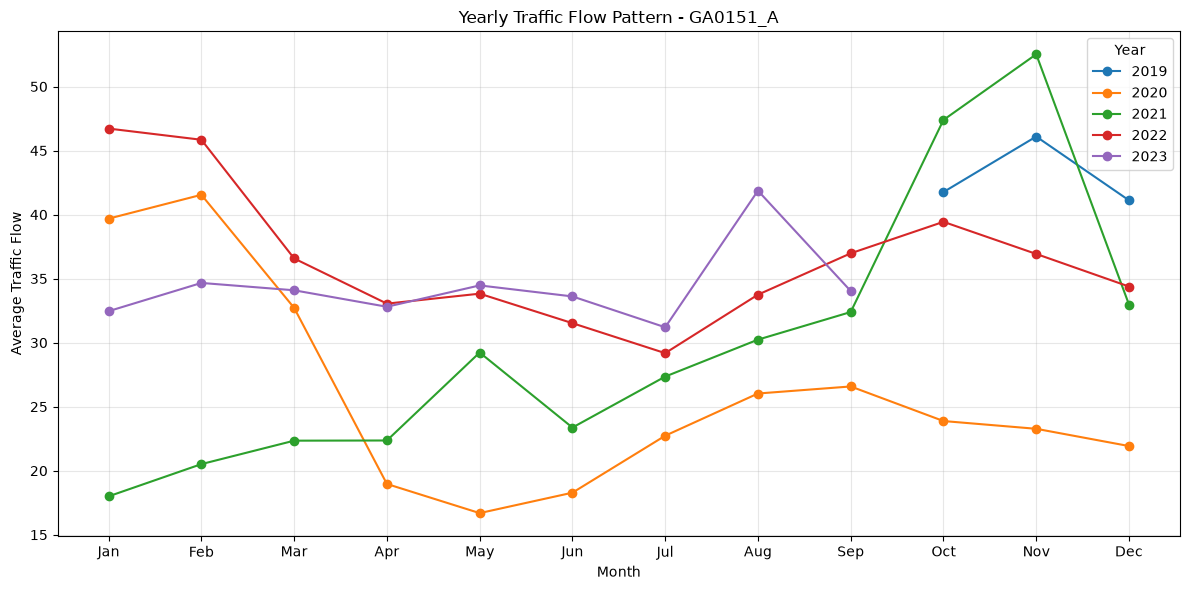

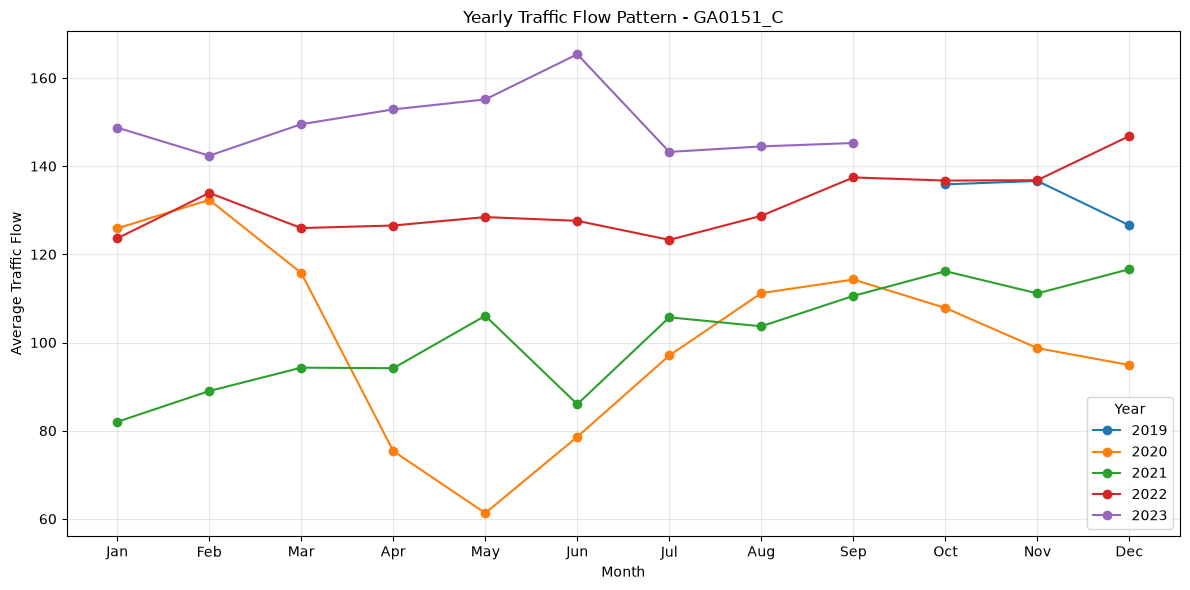

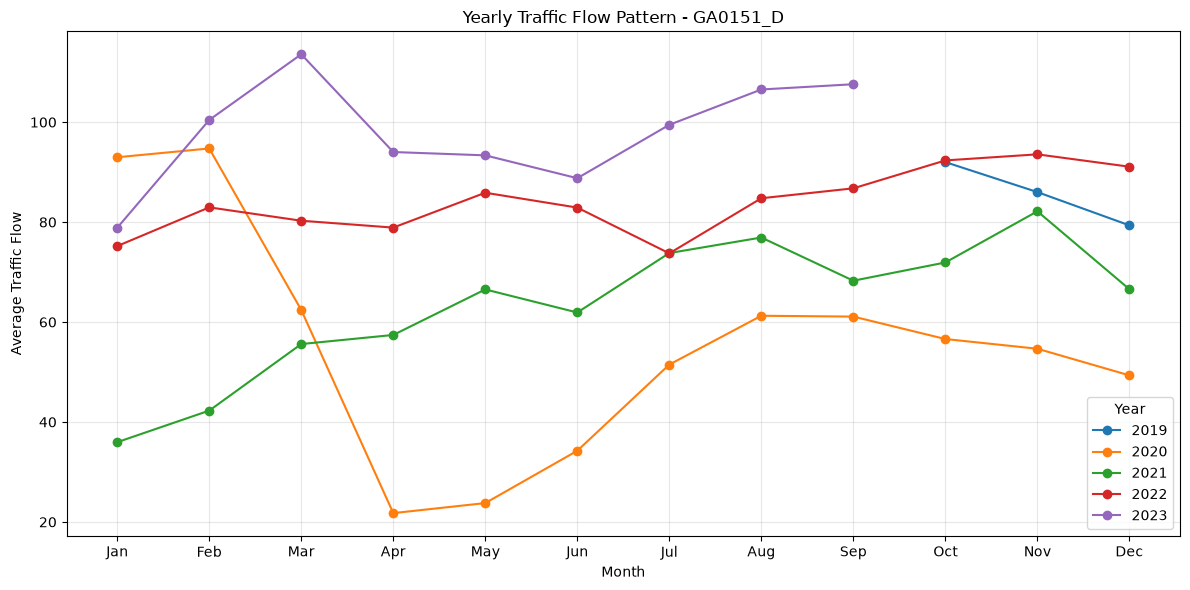

In [44]:
df['date'] = pd.to_datetime(df['date'])

sensors = ['GA0151_A', 'GA0151_C', 'GA0151_D']

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for sensor in sensors:

    yearly_pattern = (
        df.groupby(['year', 'month'])[sensor]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 6))

    for year in yearly_pattern['year'].unique():

        data = yearly_pattern[yearly_pattern['year'] == year]

        plt.plot(
            data['month'],
            data[sensor],
            marker='o',
            label=str(year)
        )

    plt.xticks(
        range(1, 13),
        month_names
    )

    plt.title(f'Yearly Traffic Flow Pattern - {sensor}')
    plt.xlabel('Month')
    plt.ylabel('Average Traffic Flow')
    plt.legend(title='Year')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


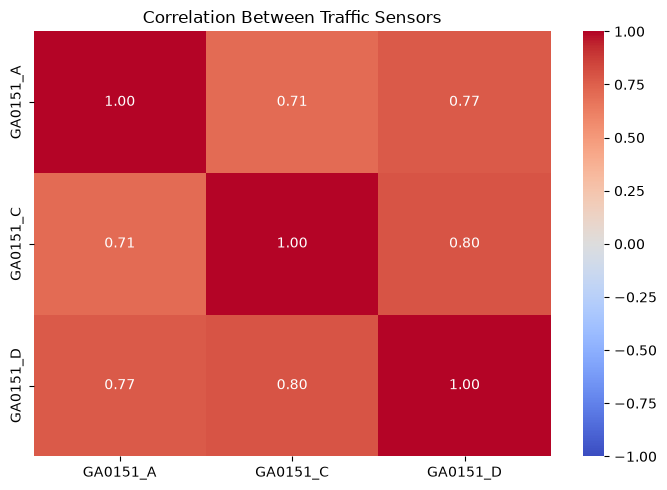

In [52]:
sensors = ['GA0151_A', 'GA0151_C', 'GA0151_D']

correlation = df[sensors].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
)

plt.title('Correlation Between Traffic Sensors')
plt.tight_layout()
plt.show()

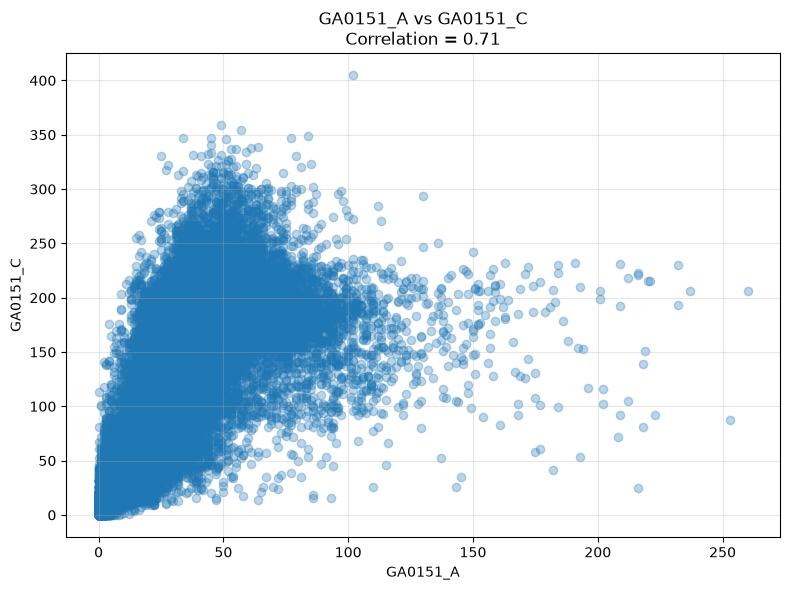

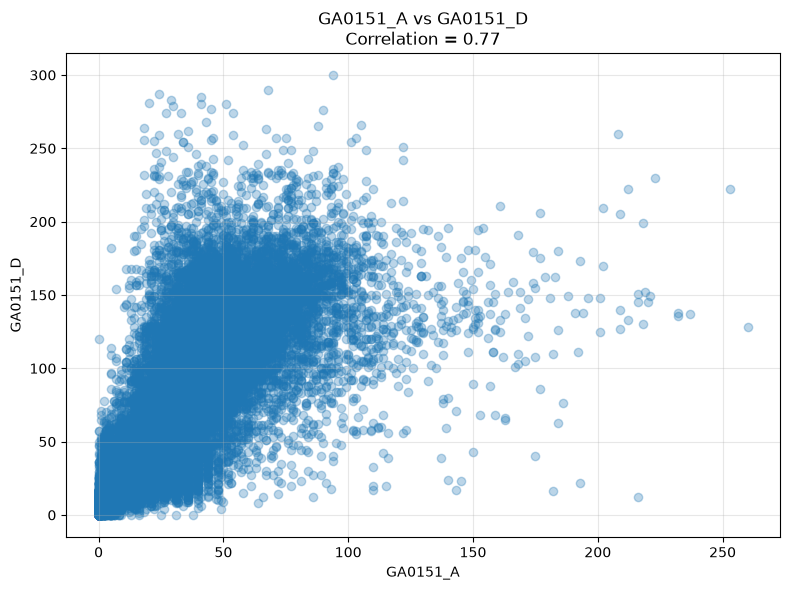

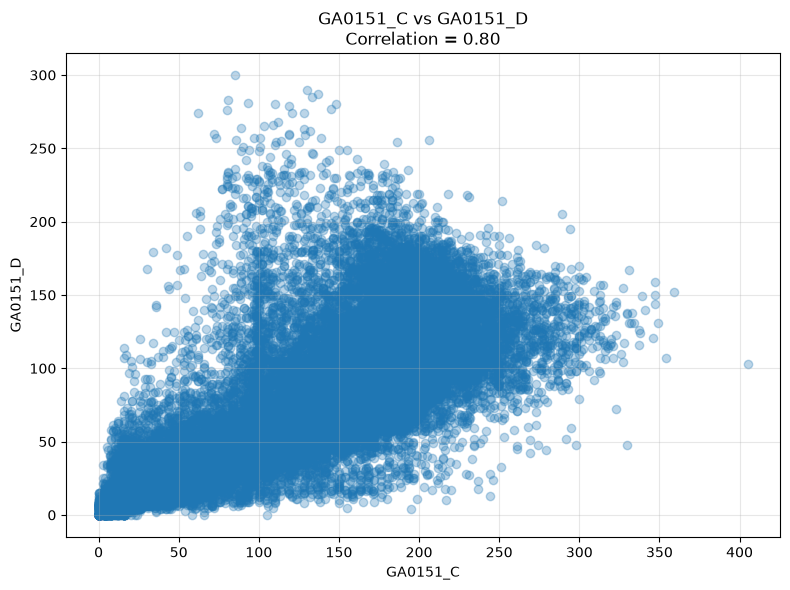

In [53]:
pairs = [
    ('GA0151_A', 'GA0151_C'),
    ('GA0151_A', 'GA0151_D'),
    ('GA0151_C', 'GA0151_D')
]

for sensor_x, sensor_y in pairs:

    plt.figure(figsize=(8, 6))

    plt.scatter(
        df[sensor_x],
        df[sensor_y],
        alpha=0.3
    )

    plt.xlabel(sensor_x)
    plt.ylabel(sensor_y)

    correlation_value = df[sensor_x].corr(df[sensor_y])

    plt.title(
        f'{sensor_x} vs {sensor_y}\n'
        f'Correlation = {correlation_value:.2f}'
    )

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

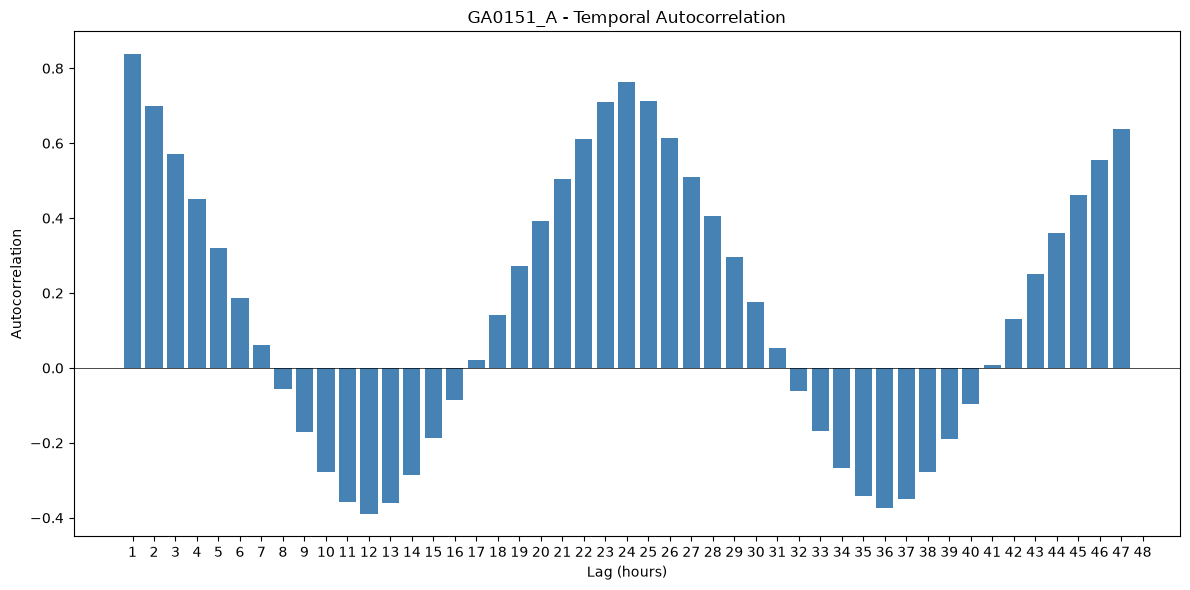


GA0151_A
Autocorrelation at lag-1:  0.837
Autocorrelation at lag-2:  0.699
Autocorrelation at lag-24: 0.764


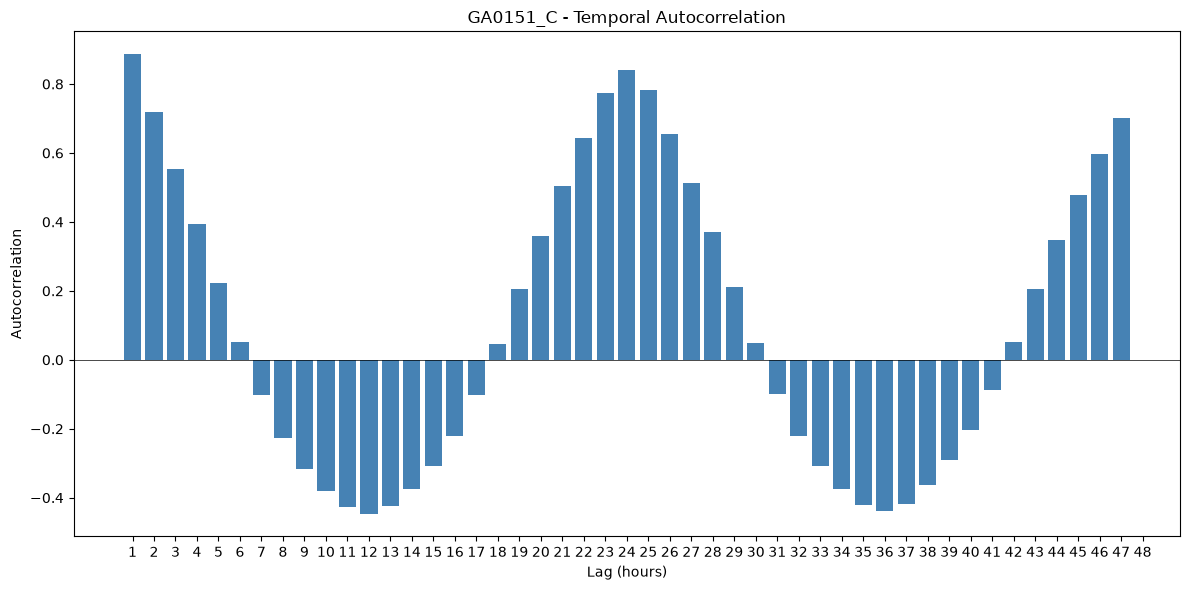


GA0151_C
Autocorrelation at lag-1:  0.886
Autocorrelation at lag-2:  0.720
Autocorrelation at lag-24: 0.841


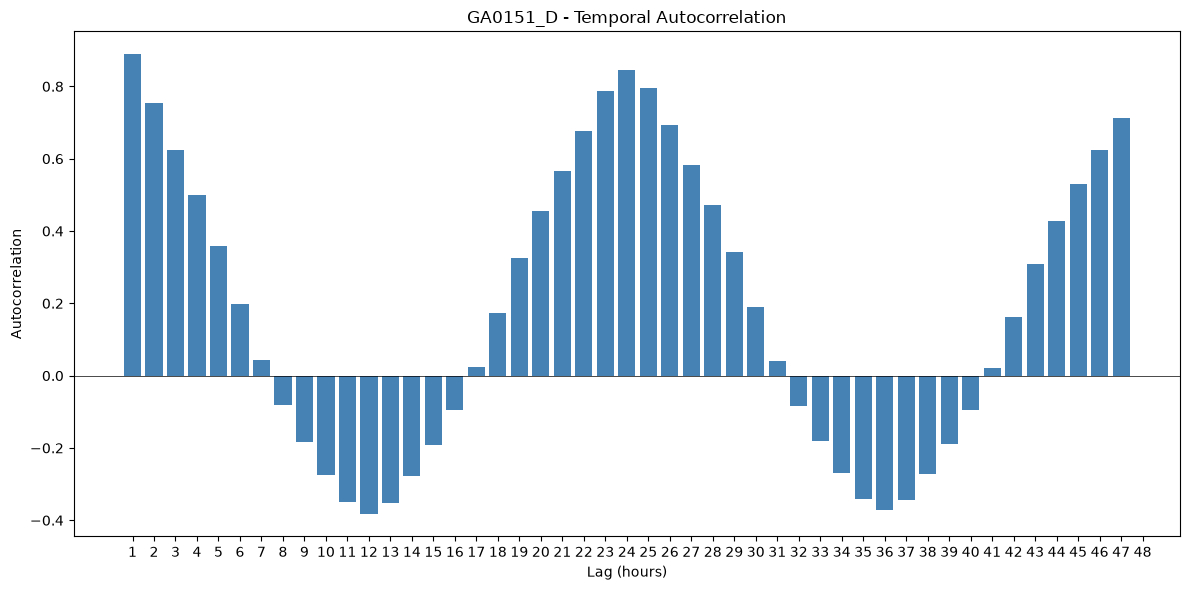


GA0151_D
Autocorrelation at lag-1:  0.889
Autocorrelation at lag-2:  0.753
Autocorrelation at lag-24: 0.845


In [ ]:
sensors = ['GA0151_A', 'GA0151_C', 'GA0151_D']

for sensor in sensors:
    lags = range(1, 48)
    autocorr = [
        df[sensor].autocorr(lag=lag)
        for lag in lags
    ]

    plt.figure(figsize=(12, 6))

    plt.bar(
        lags,
        autocorr,
        color='steelblue'
    )

    plt.axhline(
        0,
        color='black',
        linewidth=0.5
    )

    plt.xlabel('Lag (hours)')
    plt.ylabel('Autocorrelation')
    plt.title(f'{sensor} - Temporal Autocorrelation')

    plt.xticks(range(1, 49, 1))

    plt.tight_layout()
    plt.show()

    print(f'\n{sensor}')
    print(
        f'Autocorrelation at lag-1:  '
        f'{df[sensor].autocorr(lag=1):.3f}'
    )

    print(
        f'Autocorrelation at lag-2:  '
        f'{df[sensor].autocorr(lag=2):.3f}'
    )

    print(
        f'Autocorrelation at lag-24: '
        f'{df[sensor].autocorr(lag=24):.3f}'
    )


Sensor: GA0151_A
Q1: 11.00
Q3: 46.00
IQR: 35.00
Spike threshold: 98.50
Number of spikes: 516


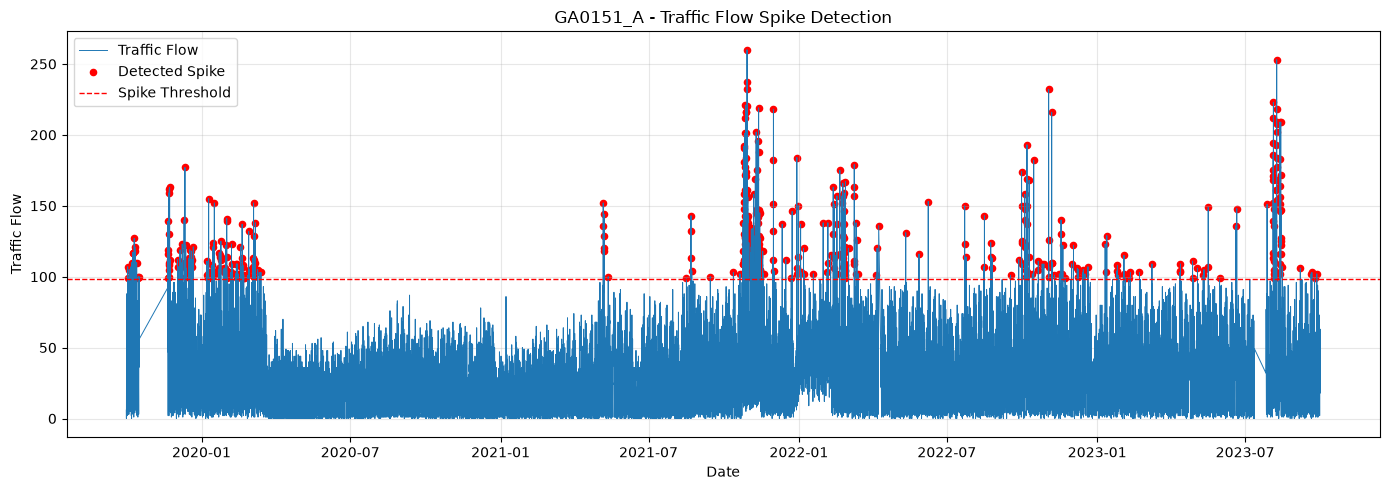


Sensor: GA0151_C
Q1: 42.00
Q3: 186.00
IQR: 144.00
Spike threshold: 402.00
Number of spikes: 1


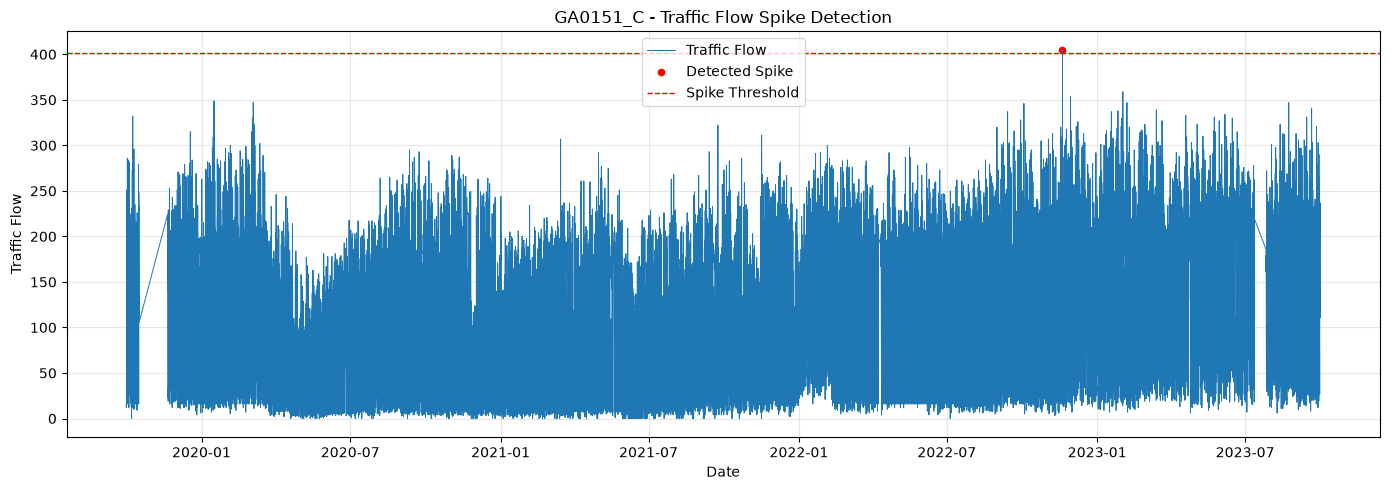


Sensor: GA0151_D
Q1: 24.00
Q3: 116.00
IQR: 92.00
Spike threshold: 254.00
Number of spikes: 31


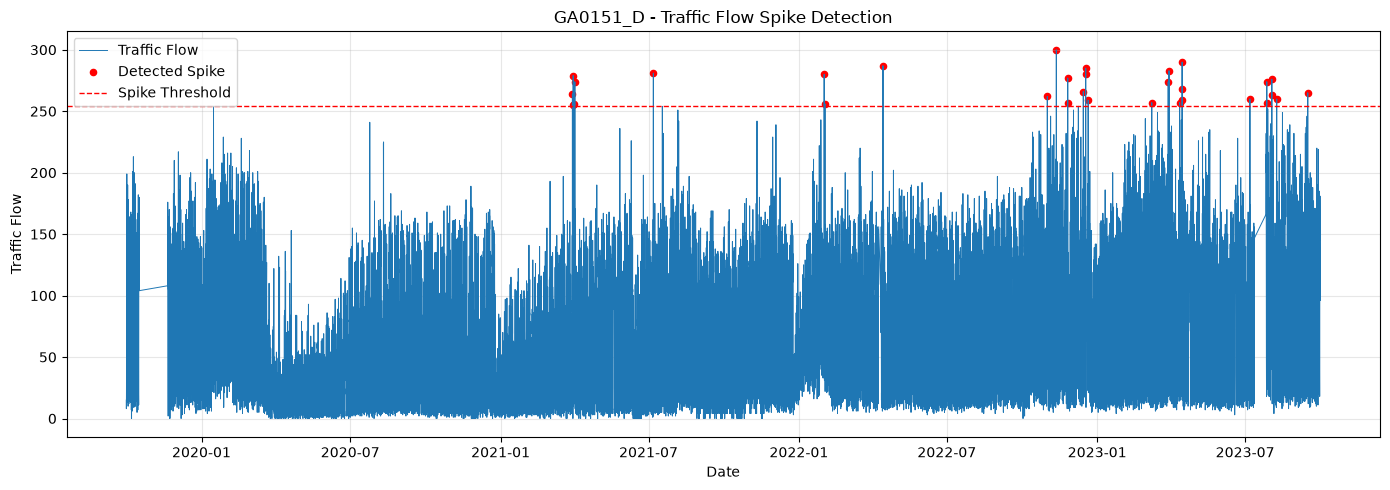

In [75]:
sensors = ['GA0151_A', 'GA0151_C', 'GA0151_D']

df['date'] = pd.to_datetime(df['date'])

df['datetime'] = df['date'] + pd.to_timedelta(df['time'], unit='h')

df = df.sort_values('datetime').reset_index(drop=True)

for sensor in sensors:

    sensor_data = df[['datetime', sensor]].dropna().copy()

    Q1 = sensor_data[sensor].quantile(0.25)
    Q3 = sensor_data[sensor].quantile(0.75)

    IQR = Q3 - Q1

    upper_limit = Q3 + 1.5 * IQR

    spikes = sensor_data[
        sensor_data[sensor] > upper_limit
    ]

    print("\n" + "=" * 50)
    print(f"Sensor: {sensor}")
    print("=" * 50)

    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Spike threshold: {upper_limit:.2f}")
    print(f"Number of spikes: {len(spikes)}")

    plt.figure(figsize=(14, 5))

    plt.plot(
        sensor_data['datetime'],
        sensor_data[sensor],
        linewidth=0.7,
        label='Traffic Flow'
    )

    plt.scatter(
        spikes['datetime'],
        spikes[sensor],
        color='red',
        s=20,
        label='Detected Spike'
    )

    plt.axhline(
        upper_limit,
        color='red',
        linestyle='--',
        linewidth=1,
        label='Spike Threshold'
    )

    plt.xlabel('Date')
    plt.ylabel('Traffic Flow')

    plt.title(
        f'{sensor} - Traffic Flow Spike Detection'
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()